# ⚾ 구종 상태 점검: 그날 그 구종이 나빠서 피한 것은 아닌가?

* **작성자:** CY
* **작성일:** 2026-10-05
* **배경:** 장타는 실투나 그날 구위가 떨어진 공에서 더 자주 나옵니다. 대조군(`field_out`)은 평균적으로 더 좋은 공입니다. 그렇다면 장타와 이후 회피가 둘 다 **"그날 그 구종이 안 좋다"는 같은 원인**에서 나왔을 수 있습니다. 이 경우 투수는 장타에 반응한 것이 아니라, 원래 알고 있던 구위 문제 때문에 덜 던진 것입니다. 지금까지의 상황 매칭(M0~M3)은 경기 상황만 맞췄고 공의 상태는 맞추지 않았습니다.
* **그날 그 구종의 상태:** 이벤트 투구 **이전**에 같은 경기에서 던진 같은 구종 투구로 잽니다. 기준은 그 투수의 시즌 평균입니다(`src/analysis/pitch_state.py`).
  * **구속 차** (mph), **헛스윙률 차** (헛스윙/스윙, 번트 제외), **피타구 xwOBA 차**
  * 이전에 잴 투구·스윙·타구가 없으면 "측정 불가"
* **확인 순서**
  1. 장타와 대조군의 그날 상태가 실제로 다른가 (균형표)
  2. 대조군만 보면, 상태가 나쁜 구종을 덜 던지는가 (대안 설명의 메커니즘이 있는가)
  3. 상태를 매칭 칸으로 추가해도 순수 감소가 남는가 (M3 + 상태, 가중 대조군 + 투수 cluster CI)
  4. 상태를 연속 공변량으로 넣은 회귀에서도 남는가
  5. 그날 상태가 나쁘지 않았던 경우만 봐도 남는가

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from IPython.display import display

from src.analysis.avoidance_stats import compute_season_usage_rate
from src.analysis.hit_quality import XWOBA, add_prior_game_usage, build_batted_ball_events
from src.analysis.pitch_state import STATE_COLUMNS, add_prior_type_state, state_buckets
from src.analysis.robust_inference import bootstrap_ci, cluster_bootstrap_did, weighted_did
from src.analysis.situation_matching import LADDER_STEPS, MODES, add_situation_columns, balance_table
from src.preprocessing.research_sample import KEY_COLUMNS, list_research_csvs

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 50)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
OUT_DIR = '../data/processed'
FIG_DIR = '../data/processed/figures'
os.makedirs(FIG_DIR, exist_ok=True)
MODE_LABELS = {'same_batter': '재대결 (메인)', 'next_batter': '다음 타자 (보조)'}
N_BOOT = 1000
SEED = 20261005

## 1. 데이터, 그날 상태, 이벤트

In [2]:
LOAD_COLUMNS = [
    'game_pk', 'game_date', 'at_bat_number', 'pitch_number', 'pitcher', 'batter', 'stand', 'p_throws',
    'pitch_type', 'events', 'description', 'balls', 'strikes', 'outs_when_up', 'inning', 'inning_topbot',
    'on_1b', 'on_2b', 'on_3b', 'home_score', 'away_score', 'launch_speed', 'launch_angle', 'release_speed',
    'plate_x', 'plate_z', XWOBA,
]
frames = [pd.read_csv(p, usecols=LOAD_COLUMNS, encoding='utf-8-sig', low_memory=False) for p in list_research_csvs()]
pitches = pd.concat(frames, ignore_index=True)
pitches['season'] = pd.to_datetime(pitches['game_date']).dt.year
assert len(pitches) == 3_592_302 and not pitches.duplicated(KEY_COLUMNS).any()
pitches = add_prior_type_state(add_prior_game_usage(add_situation_columns(pitches)))

# 이벤트 투구 자체의 상태: 그 공의 구속(시즌 평균 대비)과 한가운데 여부
# 한가운데 = |plate_x| <= 0.56ft, 1.9 <= plate_z <= 3.1ft (CSV에 타자별 존 높이가 없어 고정 근사)
season_velo = pitches.groupby(['pitcher', 'season', 'pitch_type'])['release_speed'].transform('mean')
pitches['pitch_velo_gap'] = pitches['release_speed'] - season_velo
pitches['pitch_velo_state'] = np.select(
    [pitches['pitch_velo_gap'].isna(), pitches['pitch_velo_gap'] <= -1.0, pitches['pitch_velo_gap'] >= 1.0],
    ['측정 불가', '느림', '빠름'], default='보통')
heart = (pitches['plate_x'].abs() <= 0.56) & pitches['plate_z'].between(1.9, 3.1)
pitches['location_state'] = np.where(pitches['plate_x'].isna() | pitches['plate_z'].isna(), '측정 불가',
                                     np.where(heart, '한가운데', '가장자리'))
season_usage = compute_season_usage_rate(pitches)

groups = {}
for mode in MODES:
    ev = build_batted_ball_events(pitches, season_usage, mode)
    ev = state_buckets(ev[(ev['next_ab_pitch_count'] > 0) & ev['season_usage_rate'].notna()])
    ev['diff'] = ev['season_usage_rate'] - ev['same_type_share']
    ev['group'] = ev['outcome'].isin(['2·3루타', '홈런']).astype(int)
    ev = ev[ev['outcome'].isin(['2·3루타', '홈런', '아웃'])].copy()
    groups[mode] = ev
    print(f'[{MODE_LABELS[mode]}] 장타 {ev["group"].sum():,}건, 대조군 후보 {(1 - ev["group"]).sum():,}건')
assert groups['same_batter']['group'].sum() == 27_371

[재대결 (메인)] 장타 27,371건, 대조군 후보 146,500건


[다음 타자 (보조)] 장타 66,017건, 대조군 후보 240,883건


## 2. 장타와 대조군의 그날 상태가 다른가

이벤트 투구 직전까지 그 구종의 상태를 비교합니다(측정 가능한 이벤트만). SMD는 장타 − 대조군입니다.

In [3]:
bal_rows = []
for mode, ev in groups.items():
    x, c = ev[ev['group'] == 1], ev[ev['group'] == 0]
    b = balance_table(x, c, STATE_COLUMNS)
    b['measurable_xbh'] = [x[col].notna().mean() for col in STATE_COLUMNS]
    b['measurable_ctrl'] = [c[col].notna().mean() for col in STATE_COLUMNS]
    bal_rows.append(b.assign(mode=mode))
balance = pd.concat(bal_rows).reset_index(names='variable').set_index(['mode', 'variable'])
display(balance.round(4))
balance.to_csv(f'{OUT_DIR}/pitch_state_balance.csv')

xbh_mean  placebo_mean     smd  measurable_xbh  measurable_ctrl
mode        variable                                                                  
same_batter prior_t_n    8.6835        8.7608 -0.0100          1.0000           1.0000
            velo_gap     0.0971        0.1158 -0.0193          0.9189           0.9184
            whiff_gap    0.0087        0.0151 -0.0246          0.8145           0.8190
            xwoba_gap   -0.0256       -0.0246 -0.0038          0.6992           0.7025
next_batter prior_t_n   10.6201        9.8642  0.0719          1.0000           1.0000
            velo_gap     0.0212        0.0030  0.0192          0.9191           0.8955
            whiff_gap    0.0063        0.0127 -0.0245          0.8186           0.7770
            xwoba_gap   -0.0204       -0.0164 -0.0159          0.7030           0.6461

## 3. 대안 설명의 메커니즘: 대조군에서도 상태가 나쁜 구종을 덜 던지는가

대조군(`field_out`)만으로 `diff`(시즌 구사율 − 비교 타석 비율)를 그날 상태에 회귀합니다. 계수가 양수면 그 방향일수록 덜 던진다는 뜻입니다. 상황 변수(M3 칸)를 함께 넣고, 투수 cluster 표준오차를 씁니다.
측정 불가는 0으로 채우고 결측 표시 변수를 함께 넣습니다.

In [4]:
SITUATION = 'C(season) + C(pitch_family) + C(base_out_state) + C(inning_bucket) + C(count_bucket) + C(score_diff_bucket)'


def with_state_terms(df):
    d = df.copy()
    for col in ['velo_gap', 'whiff_gap', 'xwoba_gap']:
        d[f'{col}_na'] = d[col].isna().astype(int)
        d[col] = d[col].fillna(0.0)
    return d


STATE_TERMS = 'velo_gap + velo_gap_na + whiff_gap + whiff_gap_na + xwoba_gap + xwoba_gap_na + np.log1p(prior_t_n)'
mech_rows = []
for mode, ev in groups.items():
    d = with_state_terms(ev[ev['group'] == 0])
    fit = smf.ols(f'diff ~ {STATE_TERMS} + {SITUATION}', data=d).fit(cov_type='cluster', cov_kwds={'groups': d['pitcher']})
    for t in ['velo_gap', 'whiff_gap', 'xwoba_gap']:
        lo, hi = fit.conf_int().loc[t]
        mech_rows.append({'mode': mode, 'term': t, 'coef': fit.params[t], 'ci_low': lo, 'ci_high': hi, 'p': fit.pvalues[t]})
mechanism = pd.DataFrame(mech_rows).set_index(['mode', 'term'])
display(mechanism.round(4))
mechanism.to_csv(f'{OUT_DIR}/pitch_state_mechanism.csv')
print('읽는 법: velo_gap 계수 -0.01이면 그날 구속이 1mph 느릴 때 비교 타석에서 그 구종을 1%p 덜 던짐')

coef  ci_low  ci_high       p
mode        term                                      
same_batter velo_gap  -0.0021 -0.0042   0.0001  0.0635
            whiff_gap -0.0127 -0.0192  -0.0062  0.0001
            xwoba_gap  0.0285  0.0214   0.0356  0.0000
next_batter velo_gap   0.0001 -0.0013   0.0015  0.8793
            whiff_gap -0.0162 -0.0207  -0.0118  0.0000
            xwoba_gap  0.0607  0.0547   0.0666  0.0000

읽는 법: velo_gap 계수 -0.01이면 그날 구속이 1mph 느릴 때 비교 타석에서 그 구종을 1%p 덜 던짐


## 4. 상태를 매칭 칸에 추가: 순수 감소가 남는가

M3 칸에 상태 칸(구속 / 헛스윙 / 피타구, 각각 측정 불가·나쁨·보통·좋음)을 더합니다. 대조군은 칸마다 조건에 맞는 `field_out` 전부를 가중하고(노트북 06), CI는 투수 cluster 부트스트랩입니다.

In [5]:
M3 = list(LADDER_STEPS['M3'])
SPECS = {
    'M3': M3,
    'M3 + 구속': M3 + ['velo_state'],
    'M3 + 헛스윙': M3 + ['whiff_state'],
    'M3 + 피타구': M3 + ['xwoba_state'],
    'M3 + 상태 전부': M3 + ['velo_state', 'whiff_state', 'xwoba_state'],
}
rows = []
for mode, ev in groups.items():
    x, c = ev[ev['group'] == 1], ev[ev['group'] == 0]
    for name, strata in SPECS.items():
        r = weighted_did(x, c, strata)
        lo, hi = bootstrap_ci(r['net'], cluster_bootstrap_did(x, c, strata, n_boot=N_BOOT, seed=SEED))
        rows.append({'mode': mode, 'spec': name, 'n_xbh': r['n_xbh'], 'retention': r['n_xbh'] / r['n_xbh_all'],
                     'net': r['net'], 'ci_low': lo, 'ci_high': hi})
matched = pd.DataFrame(rows).set_index(['mode', 'spec'])
show = matched.copy(); show[['net', 'ci_low', 'ci_high']] *= 100
display(show.round(3))
matched.to_csv(f'{OUT_DIR}/pitch_state_matched.csv')

n_xbh  retention     net  ci_low  ci_high
mode        spec                                                 
same_batter M3          26951      0.985  14.311  13.832   14.758
            M3 + 구속     26049      0.952  14.244  13.718   14.712
            M3 + 헛스윙    25970      0.949  14.167  13.663   14.643
            M3 + 피타구    25966      0.949  14.354  13.816   14.786
            M3 + 상태 전부  20894      0.763  13.920  13.232   14.533
next_batter M3          45654      0.692   6.753   6.426    7.053
            M3 + 구속     44300      0.671   6.674   6.342    7.006
            M3 + 헛스윙    44230      0.670   6.678   6.353    7.001
            M3 + 피타구    44267      0.671   6.731   6.373    7.061
            M3 + 상태 전부  37314      0.565   6.561   6.176    6.955

## 5. 회귀 보정: 상태를 연속 변수로 넣어도 남는가

`diff ~ group + 상황(M3 칸) [+ 그날 상태]`, 투수 cluster 표준오차. 상태를 넣기 전후의 `group` 계수(= 순수 감소)를 비교합니다.

In [6]:
reg_rows = []
for mode, ev in groups.items():
    d = with_state_terms(ev)
    for name, rhs in [('상황만', f'group + {SITUATION}'), ('상황 + 그날 상태', f'group + {STATE_TERMS} + {SITUATION}')]:
        fit = smf.ols(f'diff ~ {rhs}', data=d).fit(cov_type='cluster', cov_kwds={'groups': d['pitcher']})
        lo, hi = fit.conf_int().loc['group']
        reg_rows.append({'mode': mode, 'model': name, 'n': int(fit.nobs), 'group_coef': fit.params['group'],
                         'ci_low': lo, 'ci_high': hi})
reg = pd.DataFrame(reg_rows).set_index(['mode', 'model'])
show = reg.copy(); show[['group_coef', 'ci_low', 'ci_high']] *= 100
display(show.round(3))
reg.to_csv(f'{OUT_DIR}/pitch_state_regression.csv')

n  group_coef  ci_low  ci_high
mode        model                                          
same_batter 상황만         173871      14.378  13.937   14.820
            상황 + 그날 상태  173871      14.398  13.956   14.839
next_batter 상황만         306900       6.690   6.391    6.990
            상황 + 그날 상태  306900       6.717   6.418    7.016

## 5-1. 장타를 맞은 공 자체가 실투였나

위 상태는 이벤트 **이전** 투구로 잰 것이라, 장타를 맞은 **그 공**이 한가운데로 몰렸거나 구속이 떨어진 실투였는지는 반영하지 않습니다. 이벤트 투구의 위치(한가운데 / 가장자리)와 구속(시즌 평균 대비 ±1mph)을 비교하고, 매칭 칸에 더해 봅니다.

In [7]:
pitch_rows = []
for mode, ev in groups.items():
    x, c = ev[ev['group'] == 1], ev[ev['group'] == 0]
    pitch_rows.append({'mode': mode,
                       'heart_xbh': (x['location_state'] == '한가운데').mean(),
                       'heart_ctrl': (c['location_state'] == '한가운데').mean(),
                       'velo_gap_xbh': x['pitch_velo_gap'].mean(), 'velo_gap_ctrl': c['pitch_velo_gap'].mean()})
display(pd.DataFrame(pitch_rows).set_index('mode').round(3))

PITCH_SPECS = {
    'M3 + 공 위치': M3 + ['location_state'],
    'M3 + 공 구속': M3 + ['pitch_velo_state'],
    'M3 + 공 위치·구속 + 그날 상태': M3 + ['location_state', 'pitch_velo_state', 'velo_state', 'whiff_state', 'xwoba_state'],
}
rows = []
for mode, ev in groups.items():
    x, c = ev[ev['group'] == 1], ev[ev['group'] == 0]
    for name, strata in PITCH_SPECS.items():
        r = weighted_did(x, c, strata)
        lo, hi = bootstrap_ci(r['net'], cluster_bootstrap_did(x, c, strata, n_boot=N_BOOT, seed=SEED))
        rows.append({'mode': mode, 'spec': name, 'n_xbh': r['n_xbh'], 'retention': r['n_xbh'] / r['n_xbh_all'],
                     'net': r['net'], 'ci_low': lo, 'ci_high': hi})
pitch_matched = pd.DataFrame(rows).set_index(['mode', 'spec'])
show = pitch_matched.copy(); show[['net', 'ci_low', 'ci_high']] *= 100
display(show.round(3))
pitch_matched.to_csv(f'{OUT_DIR}/pitch_state_event_pitch.csv')
matched = pd.concat([matched, pitch_matched])
SPECS.update(PITCH_SPECS)

,heart_xbh,heart_ctrl,velo_gap_xbh,velo_gap_ctrl
mode,,,,
same_batter,0.581,0.453,0.035,0.117
next_batter,0.579,0.456,-0.074,-0.088


n_xbh  retention     net  ci_low  ci_high
mode        spec                                                           
same_batter M3 + 공 위치             26496      0.968  14.087  13.568   14.545
            M3 + 공 구속             26282      0.960  14.322  13.815   14.793
            M3 + 공 위치·구속 + 그날 상태  14188      0.518  13.567  12.707   14.280
next_batter M3 + 공 위치             45014      0.682   6.743   6.412    7.035
            M3 + 공 구속             44676      0.677   6.655   6.337    6.986
            M3 + 공 위치·구속 + 그날 상태  27126      0.411   6.675   6.220    7.228

## 6. 그날 상태가 나쁘지 않았던 경우만

이벤트 직전까지 그 구종이 **느리지 않았고, 헛스윙이 적지 않았고, 강하게 맞지 않았던** 경우(측정 불가는 포함)만 남겨 M3 가중 순수 감소를 다시 냅니다. 이 경우 장타는 "그날 나쁜 공"에서 나온 것이라고 보기 어렵습니다.

In [8]:
ok_rows = []
for mode, ev in groups.items():
    good = ev[(ev['velo_state'] != '느림') & (ev['whiff_state'] != '헛스윙 적음') & (ev['xwoba_state'] != '강하게 맞음')]
    x, c = good[good['group'] == 1], good[good['group'] == 0]
    r = weighted_did(x, c, M3)
    lo, hi = bootstrap_ci(r['net'], cluster_bootstrap_did(x, c, M3, n_boot=N_BOOT, seed=SEED))
    ok_rows.append({'mode': mode, 'share_of_xbh': len(x) / ev['group'].sum(), 'n_xbh': r['n_xbh'],
                    'net': r['net'], 'ci_low': lo, 'ci_high': hi})
good_only = pd.DataFrame(ok_rows).set_index('mode')
show = good_only.copy(); show[['net', 'ci_low', 'ci_high']] *= 100
display(show.round(3))
good_only.to_csv(f'{OUT_DIR}/pitch_state_good_only.csv')

,share_of_xbh,n_xbh,net,ci_low,ci_high
mode,,,,,
same_batter,0.499,13264,14.226,13.692,14.763
next_batter,0.507,23067,6.555,6.124,6.965


## 7. 그래프

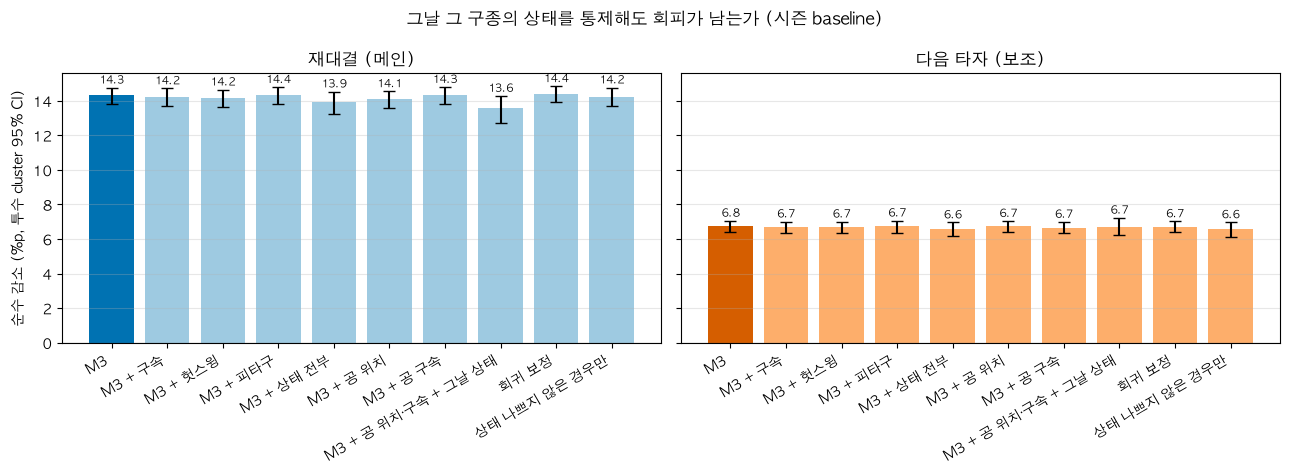

In [9]:
summary_rows = []
for mode in MODES:
    for spec in SPECS:
        r = matched.loc[(mode, spec)]
        summary_rows.append({'mode': mode, 'label': spec, 'net': r['net'], 'lo': r['ci_low'], 'hi': r['ci_high']})
    r = reg.loc[(mode, '상황 + 그날 상태')]
    summary_rows.append({'mode': mode, 'label': '회귀 보정', 'net': r['group_coef'], 'lo': r['ci_low'], 'hi': r['ci_high']})
    r = good_only.loc[mode]
    summary_rows.append({'mode': mode, 'label': '상태 나쁘지 않은 경우만', 'net': r['net'], 'lo': r['ci_low'], 'hi': r['ci_high']})
fig_df = pd.DataFrame(summary_rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
colors = {'same_batter': '#0072B2', 'next_batter': '#D55E00'}
for ax, mode in zip(axes, MODES):
    d = fig_df[fig_df['mode'] == mode].reset_index(drop=True)
    y = d['net'] * 100
    ax.bar(range(len(d)), y, color=[colors[mode] if i == 0 else '#9ecae1' if mode == 'same_batter' else '#fdae6b' for i in range(len(d))],
           yerr=[y - d['lo'] * 100, d['hi'] * 100 - y], capsize=4)
    for i, (v, top) in enumerate(zip(y, d['hi'] * 100)):
        ax.annotate(f'{v:.1f}', (i, top), textcoords='offset points', xytext=(0, 3), ha='center', fontsize=8)
    ax.set_xticks(range(len(d)), d['label'], rotation=30, ha='right')
    ax.set_title(MODE_LABELS[mode])
    ax.axhline(0, color='grey', lw=0.8)
    ax.grid(axis='y', alpha=0.3)
axes[0].set_ylabel('순수 감소 (%p, 투수 cluster 95% CI)')
fig.suptitle('그날 그 구종의 상태를 통제해도 회피가 남는가 (시즌 baseline)')
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/pitch_state_control.png', dpi=150)
plt.show()

## 8. 해석 (시즌 baseline, 가중 대조군 + 투수 cluster 95% CI)

* **장타 이전의 그날 상태는 장타군과 대조군이 거의 같습니다.** 이벤트 직전까지 그 구종의 구속 차, 헛스윙률 차, 피타구 xwOBA 차의 SMD가 모두 |0.03| 이하입니다. "장타는 그날 안 좋던 구종에서 나온다"는 전제 자체가 이 데이터에서는 거의 성립하지 않습니다.
* **대안 설명의 메커니즘은 있지만 아주 작습니다.** 대조군만 보면 그날 강하게 맞던 구종(피타구 xwOBA +0.1)은 재대결에서 약 0.3%p, 헛스윙이 적던 구종(헛스윙률 −10%p)은 약 0.1%p 덜 던집니다. 구속 차는 재대결에서 경계선(p = 0.06), 다음 타자에서 효과가 없습니다. 투수가 그날 상태에 반응하긴 하지만, 장타 후 회피(14%p)와 비교하면 무시할 만한 크기입니다.
* **장타를 맞은 공 자체는 실투가 더 많습니다.** 장타가 된 공의 58%가 한가운데였고, 대조군 아웃은 45%였습니다. 그런데 공의 위치를 매칭 칸에 넣어도 재대결 순수 감소는 14.31 → **14.09%p**로 거의 그대로입니다. 공 구속은 차이가 작고(시즌 대비 +0.04 vs +0.12mph) 매칭해도 14.32%p입니다.
* **모두 통제해도 남습니다.** 재대결 기준으로 정리하면 다음과 같습니다.

  | 통제한 것 | 순수 감소 | 95% CI | 장타 유지율 |
  |---|---:|---|---:|
  | M3 (기준) | 14.31%p | [13.83, 14.76] | 98% |
  | + 그날 상태 3가지 (칸) | 13.92%p | [13.23, 14.53] | 76% |
  | + 공 위치·구속 + 그날 상태 (칸) | 13.57%p | [12.71, 14.28] | 52% |
  | + 그날 상태 (연속 공변량, 회귀) | 14.40%p | [13.96, 14.84] | 100% |
  | 그날 상태가 나쁘지 않았던 경우만 | 14.23%p | [13.69, 14.76] | 50% |

  가장 많이 통제한 경우에도 0.7%p(약 5%)만 줄고, 신뢰구간이 M3와 겹칩니다. 다음 타자도 6.75 → 6.56~6.75%p로 같습니다.
* **결론.** "그날 그 구종이 나빠서 원래 덜 던질 공이었다"는 설명으로는 회피의 극히 일부(최대 약 5%)만 설명됩니다. 장타 뒤 회피는 그날 구종 상태나 실투 여부와 독립적으로 나타나는, **장타라는 사건에 대한 반응**으로 보는 것이 타당합니다. 타자 맞춤 점검(노트북 05: 회피가 그 타자에게 집중됨)와도 맞아떨어집니다. 구종이 그날 나빴다면 중간 타자에게도 비슷하게 피했어야 합니다.
* **한계.**
  * 그날 상태는 이벤트 이전 투구로만 잴 수 있어, 그날 그 구종의 이전 투구·스윙·타구가 없어 잴 수 없는 경우(구속 약 8%, 헛스윙 약 19%, 피타구 약 30%)는 "측정 불가" 칸으로 따로 맞췄습니다.
  * 한가운데 판정은 타자별 스트라이크 존 높이(`sz_top`, `sz_bot`)가 없어 고정 근사입니다.
  * 무브먼트·회전수 같은 다른 구위 지표와 투수의 손 감각처럼 관측할 수 없는 요인은 남습니다.
  * 칸을 잘게 나눌수록 장타 유지율이 떨어지므로(최저 52%), 회귀 보정(유지율 100%)을 함께 봐야 합니다.